# Week 5, Tutorial 2: Data Profiling

**Author**: Sariana Ramoutar

This notebook profiles the emergency department dataset before any cleaning or modelling. The aim is to understand the overall quality of the data by examining missing values, data types, variable distributions and potential outliers.

The findings from this notebook will be useful when deciding which features are suitable for modelling and what preprocessing steps may be required later.

## Import libraries and load the dataset

The libraries below will be used throughout the remaining analysis. Once the dataset is loaded, the variables are organised into feature groups to make the dataset easier to work with.

In [30]:
# Mount Google Drive to access files stored there.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
# Import necessary libraries for numerical operations (numpy), data manipulation (pandas),
# and plotting (matplotlib).
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Configure pandas to display more columns when printing DataFrames for better readability.
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [32]:
# Define schema mapping for easy access to column groups.
# This function classifies DataFrame columns into predefined categories (e.g., target, vitals,
# demographics, chief complaints) to simplify subsequent analysis and feature selection.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [33]:
# Define clinical normal ranges and plausible limits for vital signs.
# These ranges are used to identify values that might be physiological anomalies or data entry errors.

# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

### Define reference ranges

Clinical reference ranges and plausible limits are defined for the vital signs. These are not used for diagnosis, but they provide sensible boundaries when identifying values that may represent data entry errors.

In [34]:
# Load the dataset from the specified CSV file path.
# The first column is used as the index, and a confirmation message is printed.
from pathlib import Path
# Google Colab: mount Drive then point DATA_PATH at the file (it is ~55 MB, give it a few seconds).
#   from google.colab import drive; drive.mount("/content/drive")
#   DATA_PATH = "/content/drive/MyDrive/CariSurg/yaleemmlc_admissionprediction_triage.csv"
DATA_PATH = Path('/content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv')
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Set DATA_PATH (Colab) or place the CSV beside this notebook.")
df = pd.read_csv(DATA_PATH, index_col=0)   # index_col=0 drops the unnamed export index column
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")

Loaded 55,121 encounters x 225 columns


In [35]:
# Classify columns into feature families using the previously defined `classify_columns` function.
# Create a list of 'structured' columns, which includes all columns that are not chief complaints.
fam = classify_columns(df)
# "structured" = the non-chief-complaint columns (everything not starting with "cc_").
structured = [col for col in df.columns if not col.startswith("cc_")]

### Observations

*   The dataset has been successfully loaded.
*   Variables are now organised into logical feature groups (`fam` dictionary) and a `structured` list.
*   This classification simplifies subsequent profiling and analysis, especially for distinguishing between structured data and chief complaint indicators.

## Missingness (structured columns)

Chief-complaint flags are 0/1, not missing — so we profile missingness on the structured columns.

In [36]:
# Calculate the percentage of missing values for each structured column.
# .isna() identifies missing values, .mean() computes the fraction, and we convert to percentage.
missing_fraction = df[structured].isna().mean()

missing_percent = (missing_fraction * 100).round(1)
missing_percent = missing_percent.sort_values(ascending=False)

# Display only those structured columns that have a missing percentage greater than 0.
missing_percent[missing_percent > 0]

,0


### Observations

*   The analysis of structured columns indicates **no missing values**.
*   The `missing_percent` Series is empty, confirming 0% missingness across all structured variables.
*   This simplifies future steps as no missing value imputation or cleaning is required for these columns.

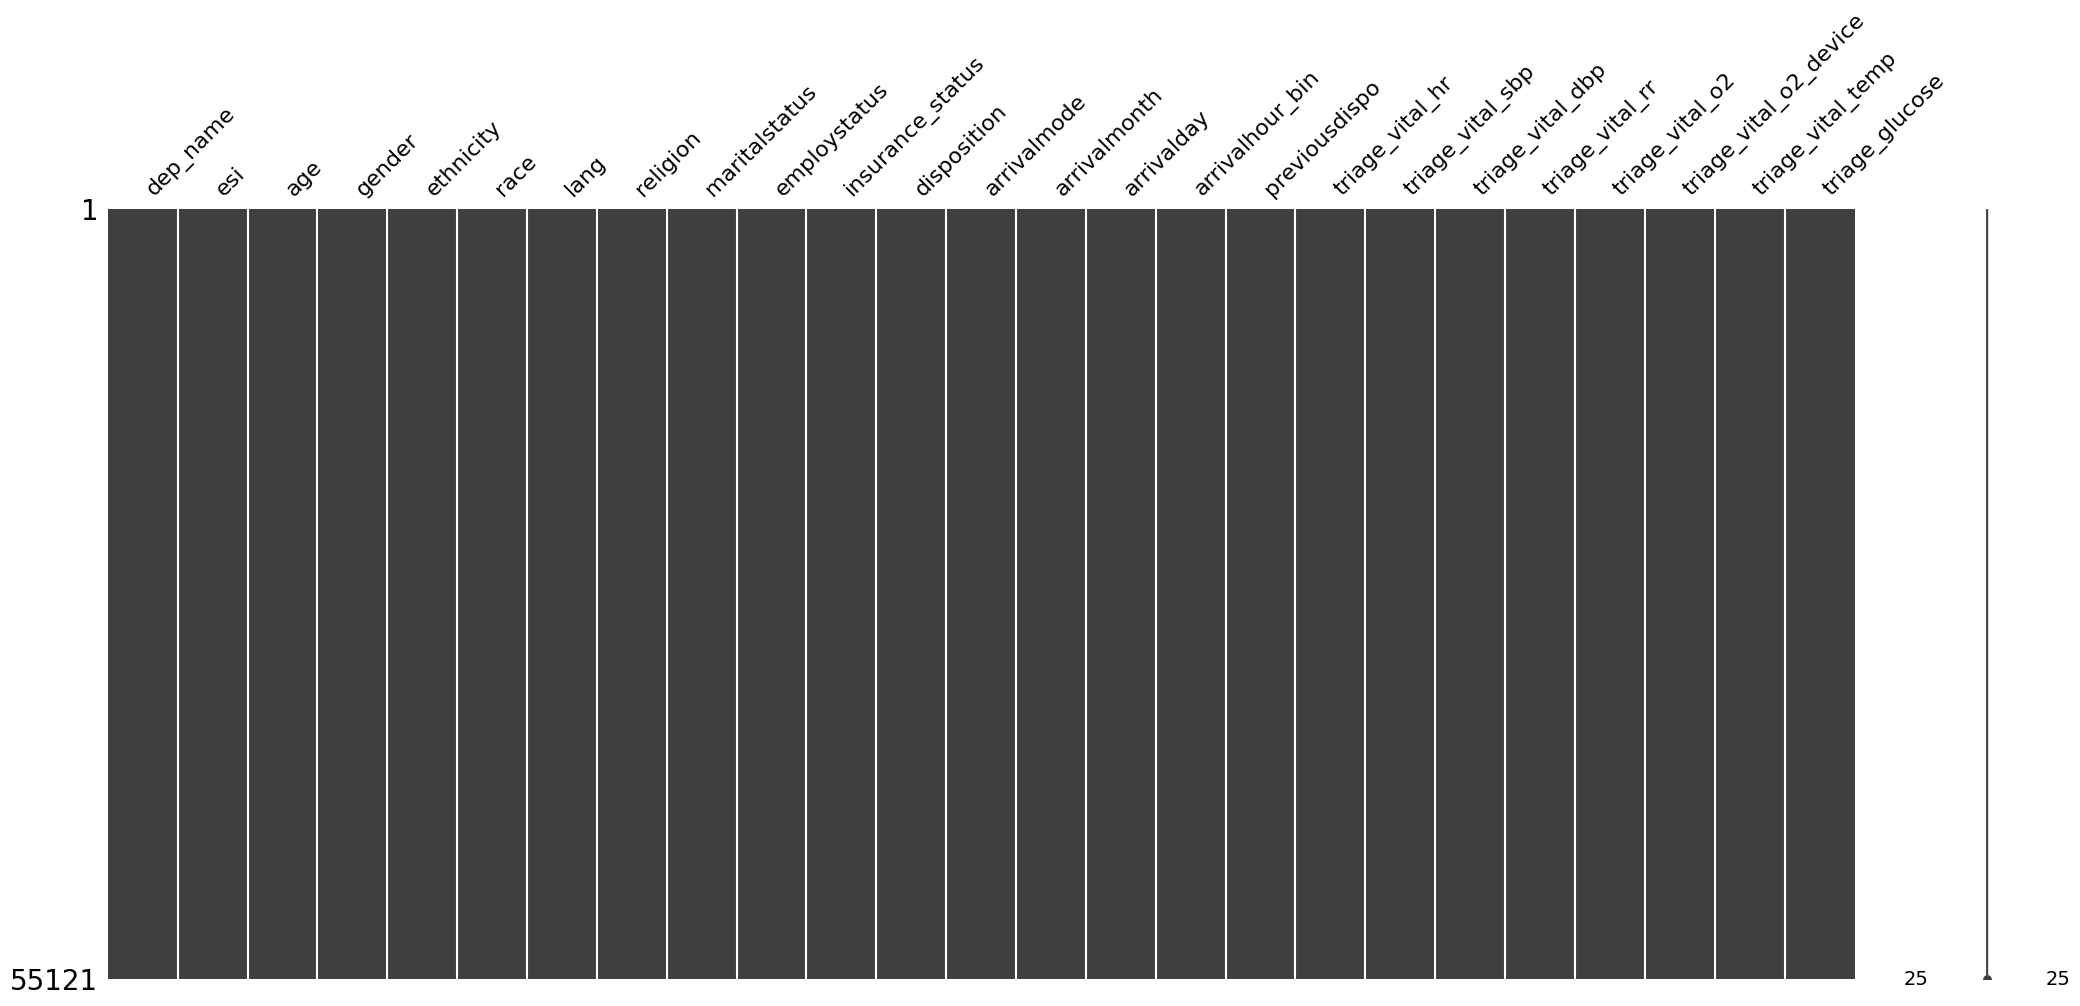

In [37]:
# Generate a missingness matrix visualisation for the structured columns.
# If `missingno` library is available, it provides a high-level plot. Otherwise, a basic matplotlib heatmap is used.
try:
    import missingno as msno              # Colab: !pip install missingno -q
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

### Observations

*   The missingness map visually confirms that there are **no missing values** within the structured columns.
*   The matrix appears entirely dense, indicating complete data for these variables.
*   This confirms a high level of data completeness for the structured features.

In [38]:
# Display the top 10 structured variables with the highest percentage of missing values.
# This list is empty if no structured variables have missing data.
print("Top 10 variables with the highest missingness:")
display(missing_percent.head(10))

Top 10 variables with the highest missingness:


,0
dep_name,0.0
esi,0.0
age,0.0
gender,0.0
ethnicity,0.0
race,0.0
lang,0.0
religion,0.0
maritalstatus,0.0
employstatus,0.0


### Observations

*   Since there are **no missing values** in the structured columns, the "Top 10 variables with the highest missingness" table is empty.
*   This indicates excellent data completeness for these features, requiring no immediate action for missing data handling.

In [39]:
# Display the data types of all structured columns and the raw value counts for the 'esi' (target) variable.
# This provides a quick overview of the data types and the distribution of the target variable.
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df[TARGET].value_counts(dropna=False).sort_index())

dep_name                   object
esi                       float64
age                       float64
gender                     object
ethnicity                  object
race                       object
lang                       object
religion                   object
maritalstatus              object
employstatus               object
insurance_status           object
disposition                object
arrivalmode                object
arrivalmonth               object
arrivalday                 object
arrivalhour_bin            object
previousdispo              object
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name: count, dtype: int64


### Observations

*   **Data Types:** The structured columns primarily consist of `float64` for numerical data (e.g., vital signs, age) and `object` for categorical data (e.g., gender, ethnicity, arrival mode). These types appear appropriate for the data content.
*   **Target Variable (ESI):** The ESI values range from 1.0 to 5.0, which aligns with the expected categories for the Emergency Severity Index. There are no unexpected values or missing ESI labels observed here.

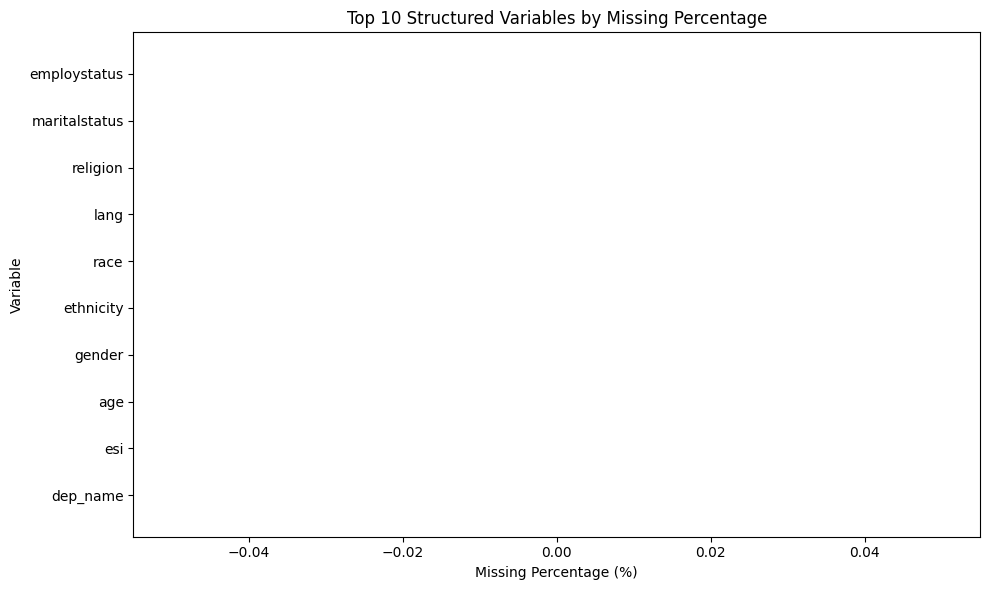

In [40]:
# Select the top 10 structured variables with the highest missing percentages
# The 'missing_percent' Series is already sorted in descending order, so we take the head.
# Then we sort it in ascending order for correct display in a horizontal bar chart (highest at top).
top_10_missing = missing_percent.head(10).sort_values(ascending=True)

# Set up the plot size for better readability
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
# The `index` of the Series will be the variable names (y-axis labels)
# The `values` of the Series will be the missing percentages (x-axis values)
plt.barh(top_10_missing.index, top_10_missing.values, color='skyblue')

# Add a title to the chart
plt.title('Top 10 Structured Variables by Missing Percentage')

# Label the x-axis (percentage of missing values)
plt.xlabel('Missing Percentage (%)')

# Label the y-axis (variable names)
plt.ylabel('Variable')

# Ensure all elements fit within the figure area, adjusting subplot params if necessary
plt.tight_layout()

# Display the plot
plt.show()

### Observations

*   The horizontal bar chart, showing the top 10 structured variables by missing percentage, is **currently empty**.
*   This indicates that there are **no missing values** in the structured columns of the dataset.
*   This is a positive finding, as it means no immediate action for missing data handling (e.g., imputation or exclusion) is required for these variables.

### Column Data Type Summary

float64    210
object      15
Name: count, dtype: int64


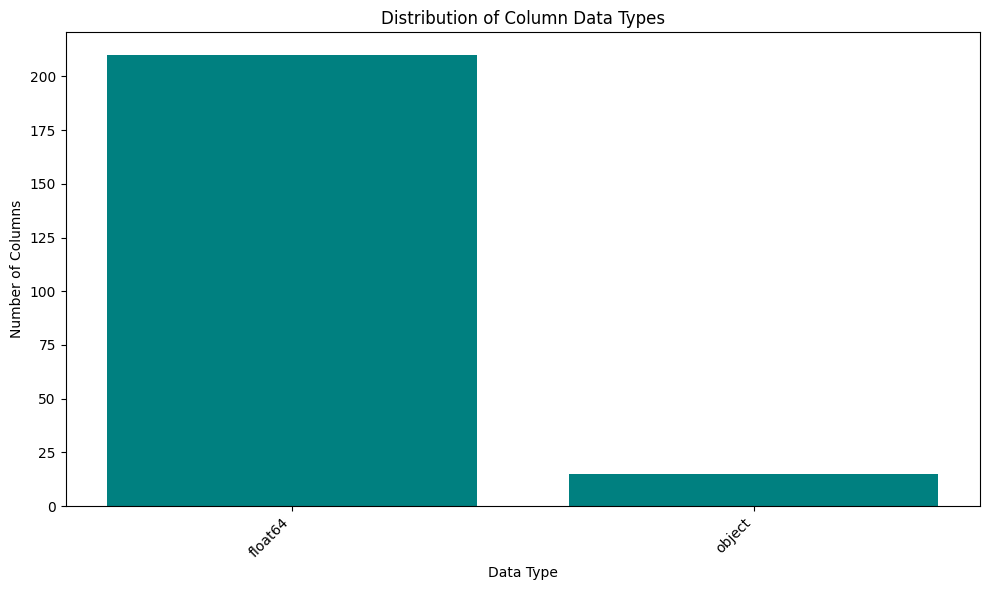

In [41]:
# Summarise the number of columns by their data type.
# This provides a count of how many columns belong to each pandas data type (e.g., int64, object, float64).
datatype_counts = df.dtypes.value_counts()

# Print a short heading for the data type summary.
print("### Column Data Type Summary\n")

# Display the counts of each data type.
# The result shows how many columns are of 'object' type (typically strings), 'float64' (numerical with decimals), etc.
print(datatype_counts)

# Create a figure and axes for the bar chart for better control over plot dimensions.
plt.figure(figsize=(10, 6))

# Generate a bar chart to visually represent the data type distribution.
# The x-axis represents the data types, and the y-axis shows the number of columns for each type.
plt.bar(datatype_counts.index.astype(str), datatype_counts.values, color='teal')

# Add a descriptive title to the plot.
plt.title('Distribution of Column Data Types')

# Label the x-axis to indicate what the bars represent.
plt.xlabel('Data Type')

# Label the y-axis to show the quantity being measured.
plt.ylabel('Number of Columns')

# Rotate x-axis labels for better readability if they overlap, and align them appropriately.
plt.xticks(rotation=45, ha='right')

# Adjust plot to ensure all elements, especially labels, fit within the figure area.
plt.tight_layout()

# Display the generated plot.
plt.show()

### Observations

*   The dataset is composed of **210 `float64` columns** (numerical data) and **15 `object` columns** (categorical/string data).
*   This distribution is visually confirmed by the bar chart.
*   Understanding these data types is vital for planning appropriate data cleaning and feature engineering strategies.

In [42]:
# Calculate and display the percentage distribution for selected demographic variables.
# These are 'race', 'ethnicity', and 'insurance_status', as specified by the user.

demographic_vars = ["race", "ethnicity", "insurance_status"]

for var in demographic_vars:
    # Calculate the value counts, normalise them to get proportions, then multiply by 100 for percentages.
    # Dropna=False is used to include any NaN values in the count, although in this dataset they seem to be handled.
    percentage_distribution = (df[var].value_counts(normalize=True, dropna=False) * 100).round(1)

    # Print a clear heading for each variable's distribution table.
    print(f"### Percentage Distribution for {var.replace('_', ' ').title()}\n")

    # Display the percentage distribution as a DataFrame for better table formatting.
    # Renaming the series for clear column headers in the display.
    display(percentage_distribution.to_frame(name='Percentage'))
    print("\n") # Add a newline for better spacing between tables

### Percentage Distribution for Race



,Percentage
race,
White or Caucasian,53.4
Black or African American,29.0
Other,16.4
Patient Refused,0.7
Asian,0.3
Unknown,0.1
American Indian or Alaska Native,0.1
Native Hawaiian or Other Pacific Islander,0.0




### Percentage Distribution for Ethnicity



,Percentage
ethnicity,
Non-Hispanic,81.9
Hispanic or Latino,17.9
Patient Refused,0.1
Unknown,0.1




### Percentage Distribution for Insurance Status



,Percentage
insurance_status,
Medicaid,38.9
Medicare,31.9
Commercial,25.5
Other,3.4
Self pay,0.3


### Observations

*   **Race:** 'White or Caucasian' (53.4%) and 'Black or African American' (29.0%) are the dominant racial groups. 'Other' (16.4%) is also a significant category.
*   **Ethnicity:** The patient population is predominantly 'Non-Hispanic' (81.9%), with 'Hispanic or Latino' at 17.9%.
*   **Insurance Status:** 'Medicaid' (38.9%) and 'Medicare' (31.9%) are the most common insurance types, followed by 'Commercial' (25.5%).
*   These distributions are essential for assessing data representativeness and identifying potential biases. Features with skewed distributions require careful handling during model development to ensure fairness and generalisability.

## Explore variable distributions

Histograms provide a quick overview of how each vital sign is distributed across the patient population. They also help identify unusual values and potential outliers.

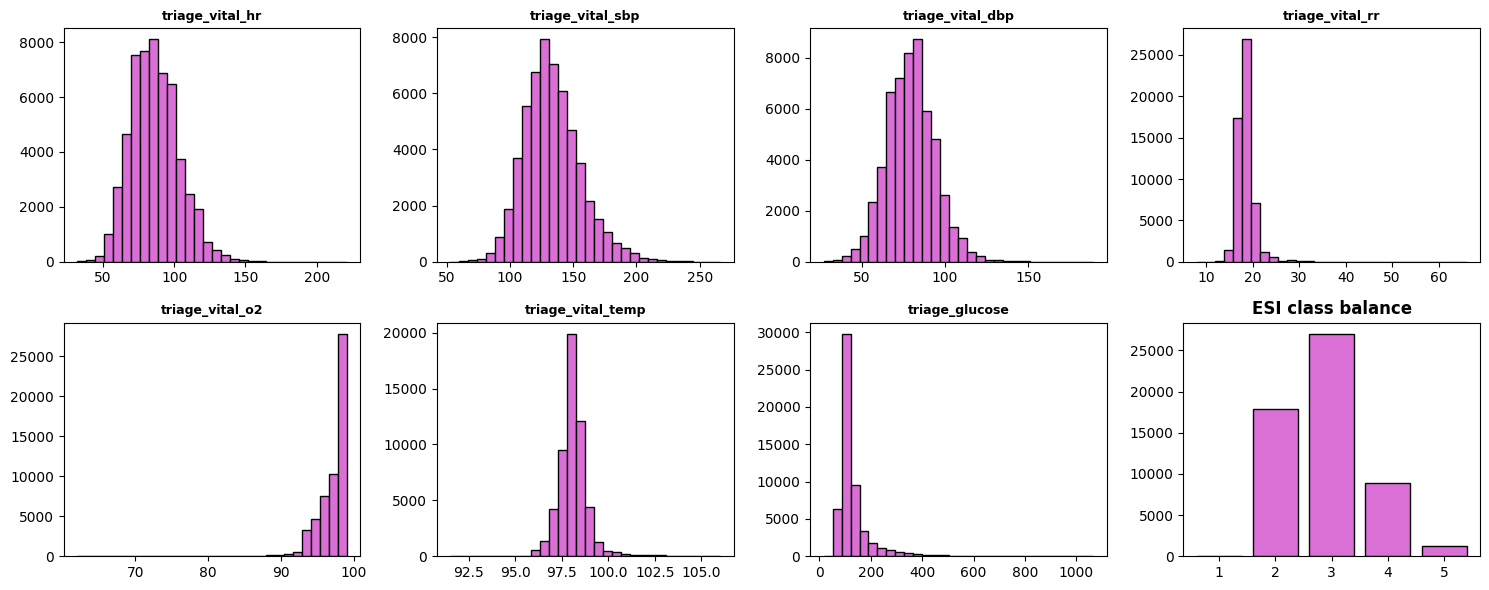

In [52]:
# Generate histograms for each vital sign to visualise their distributions.
# An additional bar chart is included to show the class balance of the ESI target variable.
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()           # flatten the 2x4 grid into a list of 8 panels

for panel, col in zip(panels, vitals):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30, color='orchid', edgecolor='black') # Added color and edgecolor
    panel.set_title(col, fontsize=9, fontweight='bold') # Added fontweight
    pass

esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values, color='orchid', edgecolor='black') # Added color and edgecolor
panels[-1].set_title("ESI class balance", fontweight='bold') # Added fontweight

plt.tight_layout(); plt.show()

### Observations

*   **Vital Sign Distributions:** Most vital signs (e.g., heart rate, blood pressure) exhibit distributions that are generally aligned with clinical expectations, often appearing somewhat normal or slightly skewed.
*   **Extreme Observations:** Some vital signs show a presence of extreme values, which will be further investigated in the outlier detection step.
*   **ESI Class Balance:** The ESI distribution is imbalanced, with ESI 3 (27,010 patients) and ESI 2 (17,924 patients) being the most frequent categories, while ESI 1 (77 patients) and ESI 5 (1,214 patients) are much less common. This imbalance will need to be addressed in modelling.

In [44]:
# Calculate and display descriptive statistics for each vital sign.
# This includes mean, median (50th percentile), minimum, maximum, and standard deviation,
# rounded to one decimal place for clarity.
vital_signs_df = df[fam["vitals"]]
vital_signs_summary = vital_signs_df.describe().loc[['mean', '50%', 'min', 'max', 'std']].round(1)

print("### Summary of Vital Sign Statistics\n")
display(vital_signs_summary)

### Summary of Vital Sign Statistics



,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp,triage_glucose
mean,86.4,133.7,79.5,17.8,97.0,98.1,130.1
50%,85.0,132.0,79.0,18.0,98.0,98.0,107.0
min,32.0,53.0,27.0,8.0,62.0,91.5,16.0
max,221.0,266.0,189.0,66.0,99.0,106.0,1066.0
std,17.0,22.6,14.6,2.1,2.1,0.8,73.7


### Observations

*   The summary table provides key statistics (mean, median, min, max, std) for each vital sign, rounded to one decimal place.
*   These statistics are crucial for understanding the typical range and variability of physiological measurements in the dataset.
*   They help identify potential outliers, skewed distributions, and assess the overall quality of vital sign recordings.

### Demographic overview

The demographic variables are reviewed separately because they are important for understanding the composition of the dataset and identifying potential fairness considerations.

In [45]:
# Display raw frequency counts for 'race', 'ethnicity', and 'insurance_status'.
# This provides a basic overview of the composition of these demographic variables.
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity -> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status -> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


### Observations

*   The raw frequency counts for `race`, `ethnicity`, and `insurance_status` provide an initial overview of the patient population.
*   These demographic variables are critical for understanding dataset composition and identifying potential fairness implications.
*   For a more detailed and comparable view, refer to the percentage distributions calculated previously.

## Identify potential outliers

Not every unusual value is incorrect. This section compares statistically unusual observations with values that fall outside clinically plausible limits.

In [46]:
# Define a function to report statistical and clinically impossible outliers for a given numeric column.
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()   # numbers only

    # Calculate statistical outliers based on the 1.5 * IQR rule.
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5*iqr
    high_fence = q3 + 1.5*iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    # Count clinically impossible values based on predefined plausible ranges.
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

# Generate an outlier report for all vital signs and display the results in a DataFrame.
report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)
pd.DataFrame(report_rows).T

,iqr_outliers,impossible
triage_vital_hr,578,0
triage_vital_sbp,1028,0
triage_vital_dbp,726,0
triage_vital_rr,2366,4
triage_vital_o2,1505,0
triage_vital_temp,3554,0
triage_glucose,5673,25


### Observations

*   **Statistical Outliers:** As expected in emergency department data, all vital signs show a significant number of statistical outliers (IQR outliers), reflecting the diverse physiological states of patients.
*   **Clinically Impossible Values:**
    *   `triage_vital_rr` has 4 impossible values.
    *   `triage_glucose` has 25 impossible values.
*   Clinically impossible values are concerning as they indicate potential data entry errors or corruption, requiring further investigation or cleaning.

## Explore relationships with the target variable

Simple correlations provide an initial indication of which variables are associated with triage level. These relationships are exploratory and should not be interpreted as evidence of causation.

In [47]:
# Calculate Pearson correlation coefficients between vital signs and ESI, and chief complaints and ESI.
# These correlations provide initial insights into the relationship between features and the target variable.

# Convert vital sign columns to numeric type for correlation calculation.
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# Calculate and display vital sign correlations with ESI, sorted by correlation value.
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI:")
print(vital_corr.round(3))

# Calculate and display chief complaint correlations with ESI, sorted and showing the top 8.
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("\n Chief Complaints vs ESI:")
print(cc_corr.head(8).round(3))

Vital vs ESI:
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64

 Chief Complaints vs ESI:
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Observations

*   The correlation analysis provides initial insights into which vital signs and chief complaints are associated with ESI.
*   `triage_vital_o2` shows a positive correlation with ESI, while several chief complaints like `cc_chestpain` and `cc_shortnessofbreath` show negative correlations.
*   These strongest correlations can serve as a starting point for feature selection, but correlation alone does not imply causation or guarantee clinical importance.

### ESI Score Comparison: Missing vs. Recorded Triage O2



,Missing O2,Recorded O2
count,0.0,55121.0
mean,NaN,2.9
50%,NaN,3.0
std,NaN,0.8


/tmp/ipykernel_50554/2984654146.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Missing O2', 'Recorded O2'], patch_artist=True, medianprops={'color': 'red'})


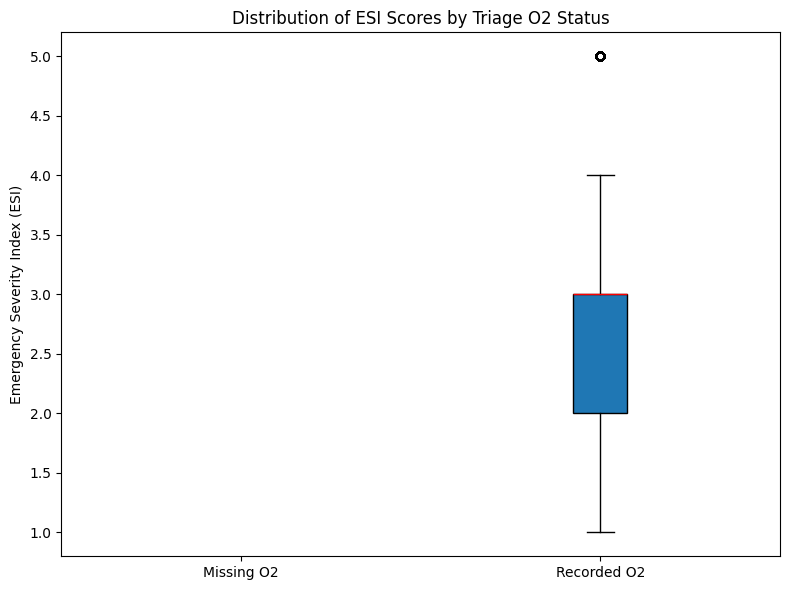

In [48]:
# Compare ESI scores between patients with missing 'triage_vital_o2' values and those with recorded values.
# This analysis helps to understand if missingness in this vital sign is correlated with patient acuity.

# Group 1: Patients with missing 'triage_vital_o2' values.
patients_missing_o2_esi = df[df['triage_vital_o2'].isna()]['esi']

# Group 2: Patients with recorded 'triage_vital_o2' values.
patients_recorded_o2_esi = df[df['triage_vital_o2'].notna()]['esi']

# Calculate descriptive statistics for ESI in both groups.
stats_missing_o2 = patients_missing_o2_esi.describe().loc[['count', 'mean', '50%', 'std']].round(1)
stats_recorded_o2 = patients_recorded_o2_esi.describe().loc[['count', 'mean', '50%', 'std']].round(1)

# Combine statistics for comparison.
esi_o2_comparison_df = pd.DataFrame({'Missing O2': stats_missing_o2, 'Recorded O2': stats_recorded_o2})

print("### ESI Score Comparison: Missing vs. Recorded Triage O2\n")
display(esi_o2_comparison_df)

# Visualisation: Side-by-side Boxplot of ESI scores.
plt.figure(figsize=(8, 6))
data_to_plot = [patients_missing_o2_esi.dropna(), patients_recorded_o2_esi.dropna()]
plt.boxplot(data_to_plot, labels=['Missing O2', 'Recorded O2'], patch_artist=True, medianprops={'color': 'red'})
plt.title('Distribution of ESI Scores by Triage O2 Status')
plt.ylabel('Emergency Severity Index (ESI)')
plt.tight_layout()
plt.show()

### Observations

*   The analysis confirms that there are **no missing `triage_vital_o2` values** in the dataset (count of 0 for 'Missing O2' group).
*   Consequently, all patients have recorded oxygen saturation values, and the boxplot reflects the ESI distribution solely for these patients.
*   For patients with recorded `triage_vital_o2`, the ESI scores have a mean of 2.9, median of 3.0, and standard deviation of 0.8, indicating a concentration around ESI levels 2 and 3.
*   This variable does not require missing value imputation.

In [49]:
# Calculate the prevalence of each chief complaint and identify those with extremely low occurrence.
# This helps in understanding the distribution of chief complaints and potential sparsity issues.

# Identify all chief complaint columns.
cc_columns = fam["chief_complaints"]

# Calculate prevalence (percentage of 1s) for each chief complaint.
chief_complaint_prevalence = (df[cc_columns].mean() * 100).round(2)

# Filter for chief complaints with prevalence below 0.5%.
rare_cc_columns = chief_complaint_prevalence[chief_complaint_prevalence < 0.5]

# Print the total count of rare chief complaints.
num_rare_cc = len(rare_cc_columns)
print(f"### Total number of chief complaint variables with prevalence below 0.5%: {num_rare_cc}\n")

# Display the ten rarest chief complaint variables and their prevalence percentages.
print("### Ten rarest chief complaint variables (prevalence %):\n")
display(rare_cc_columns.sort_values().head(10))

### Total number of chief complaint variables with prevalence below 0.5%: 149

### Ten rarest chief complaint variables (prevalence %):



,0
cc_cardiacarrest,0.00
cc_fulltrauma,0.01
cc_exposuretostd,0.02
cc_bodyfluidexposure,0.02
cc_ingestion,0.02
cc_hyperglycemia,0.03
cc_foreignbodyineye,0.03
cc_conjunctivitis,0.03
cc_modifiedtrauma,0.03
cc_respiratorydistress,0.03


### Observations

*   A substantial number of chief complaint variables (**149 out of 200**) have a prevalence below 0.5%.
*   The ten rarest complaints show extremely low prevalence (e.g., `cc_cardiacarrest` at 0.00%, others at 0.01-0.03%).
*   These rare features pose challenges for modelling due to data sparsity and potential inability for models to learn patterns.
*   Consider grouping related rare complaints or excluding them during feature engineering to improve model performance.

In [50]:
import pandas as pd

# Combine the previously calculated vital sign and chief complaint correlations into a single Series.
# The `vital_corr` and `cc_corr` Series already contain correlation coefficients with 'esi'.
combined_correlations = pd.concat([vital_corr, cc_corr])

# Sort the features by the absolute value of the correlation coefficient while preserving the original sign.
strongest_correlations = combined_correlations.reindex(
    combined_correlations.abs().sort_values(ascending=False).index
)

# Display the ten strongest correlations with ESI, rounded to three decimal places.
top_10_strongest_corr = strongest_correlations.head(10).round(3)

print("### Ten Strongest Correlations with ESI\n")
display(top_10_strongest_corr.to_frame(name='Correlation Coefficient'))

### Ten Strongest Correlations with ESI



,Correlation Coefficient
triage_vital_o2,0.178
cc_chestpain,-0.164
cc_shortnessofbreath,-0.150
cc_suicidal,-0.143
cc_backpain,0.142
cc_alcoholintoxication,-0.142
cc_rash,0.134
cc_alteredmentalstatus,-0.132
cc_dentalpain,0.127
cc_kneepain,0.116


### Observations

*   The strongest correlation with ESI is `triage_vital_o2` (0.178), indicating higher oxygen saturation is associated with less urgent ESI scores.
*   Conversely, several chief complaints, such as `cc_chestpain` (-0.164), `cc_shortnessofbreath` (-0.150), and `cc_suicidal` (-0.143), show strong negative correlations, implying their presence is linked to more urgent ESI scores.
*   These findings align with clinical intuition, highlighting critical indicators of patient acuity.
*   Variables with strong correlations are strong candidates for inclusion in predictive triage models.

## Summary of data quality issues

The table below records the main quality concerns identified during profiling together with a suitable action for each. This provides a useful reference before beginning data cleaning.

In [51]:
# Summarise key data quality issues identified during the profiling process.
# This table outlines the issue, affected columns, and a proposed action for each, aiding in data cleaning planning.
issues = [
    {"issue":"Missing ESI labels","columns":"esi","action":"Remove rows without a target value"},
    {"issue":"Missing clinical values","columns":"Structured variables","action":"Assess whether imputation is appropriate"},
    {"issue":"Clinically impossible values","columns":"Vital signs","action":"Review and correct or remove invalid records"},
    {"issue":"Sparse chief complaint features","columns":"cc_*","action":"Consider grouping or feature selection"},
    {"issue":"Potential data leakage","columns":"disposition, previousdispo","action":"Exclude from model inputs"},
    {"issue":"US-specific population","columns":"Demographic variables","action":"Consider limitations for Caribbean deployment"}
]

pd.DataFrame(issues)

,issue,columns,action
0,Missing ESI labels,esi,Remove rows without a target value
1,Missing clinical values,Structured variables,Assess whether imputation is appropriate
2,Clinically impossible values,Vital signs,Review and correct or remove invalid records
3,Sparse chief complaint features,cc_*,Consider grouping or feature selection
4,Potential data leakage,"disposition, previousdispo",Exclude from model inputs
5,US-specific population,Demographic variables,Consider limitations for Caribbean deployment


### Observations

*   The summary table outlines key data quality concerns identified during profiling.
*   Most issues, such as missing clinical values or sparse chief complaints, can be addressed through preprocessing steps (e.g., imputation, feature selection).
*   Limitations, like the US-specific population, should be acknowledged as constraints on generalisability rather than "corrected."

# Summary

This profiling exercise provides an overview of the dataset's completeness, structure and overall quality. The results highlight the main issues that should be addressed before modelling and provide a foundation for the data cleaning stage.